# 05 — Stochastic Effects: Photon Shot Noise, LER & LWR

This notebook explores **stochastic effects** in EUV lithography:

1. **Photon shot noise** — discrete nature of EUV photons
2. **LER (Line Edge Roughness)** — edge position variations
3. **LWR (Line Width Roughness)** — width variations along a line
4. **1/√Dose scaling law** — fundamental photon-statistics limit
5. **Integration into the full simulation pipeline**

**Physical background:** At 13.5 nm (91.84 eV), EUV photons are scarce. At 20 mJ/cm² only ~13 photons/nm² are absorbed. Poisson statistics → relative uncertainty → LER/LWR.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from euv.pipeline import SimulationConfig, run_simulation
from euv.resist.exposure import dose_to_acid
from euv.resist.peb import reaction_diffusion_analytical
from euv.resist.develop import threshold_development
from euv.resist.stochastic import (
    poisson_shot_noise,
    extract_edges,
    extract_ler,
    extract_lwr,
    ler_lwr_estimate,
    rms_scaling_check,
)


## 1. Photon Budget at EUV

- Photon energy: 91.84 eV = 1.47×10⁻¹⁷ J
- At 20 mJ/cm²: ~1.36×10¹⁵ photons/cm² ≈ 13.6 photons/nm²
- With quantum efficiency ≈ 0.04 → ~0.5 acid molecules/nm²

**Poisson statistics:** σ/μ = 1/√N → huge relative uncertainty at low dose.


## 2. Deterministic Acid Map (Test Case)


In [2]:
grid = 128
dx = 0.5  # nm/pixel
x = np.arange(grid) * dx
center = grid * dx / 2

# Gaussian line dose profile
dose_map = torch.tensor(
    20.0 * np.exp(-((x - center) / 10.0) ** 2),
    dtype=torch.float32,
).unsqueeze(0).expand(grid, grid).clone()

acid = dose_to_acid(
    dose_map,
    C=0.05,        # cm²/mJ
    Q=1.0,         # max acid yield
    sigma_blur=5.0,  # SE blur
    dx=dx,
)

print(f"Acid shape: {acid.shape}")
print(f"Acid range: {acid.min():.4f} – {acid.max():.4f}")


Acid shape: torch.Size([128, 128])
Acid range: 0.0015 – 0.5588


## 3. Apply Poisson Shot Noise


In [3]:
rng = torch.Generator().manual_seed(42)

noisy_acid, photon_count = poisson_shot_noise(
    acid,
    dose=dose_map,
    quantum_efficiency=0.04,
    return_photon_count=True,
    rng=rng,
)

print(f"Mean photons per voxel: {photon_count.mean():.2f}")
print(f"Noisy acid range: {noisy_acid.min():.4f} – {noisy_acid.max():.4f}")


Mean photons per voxel: 3.76
Noisy acid range: 0.0000 – 0.7367


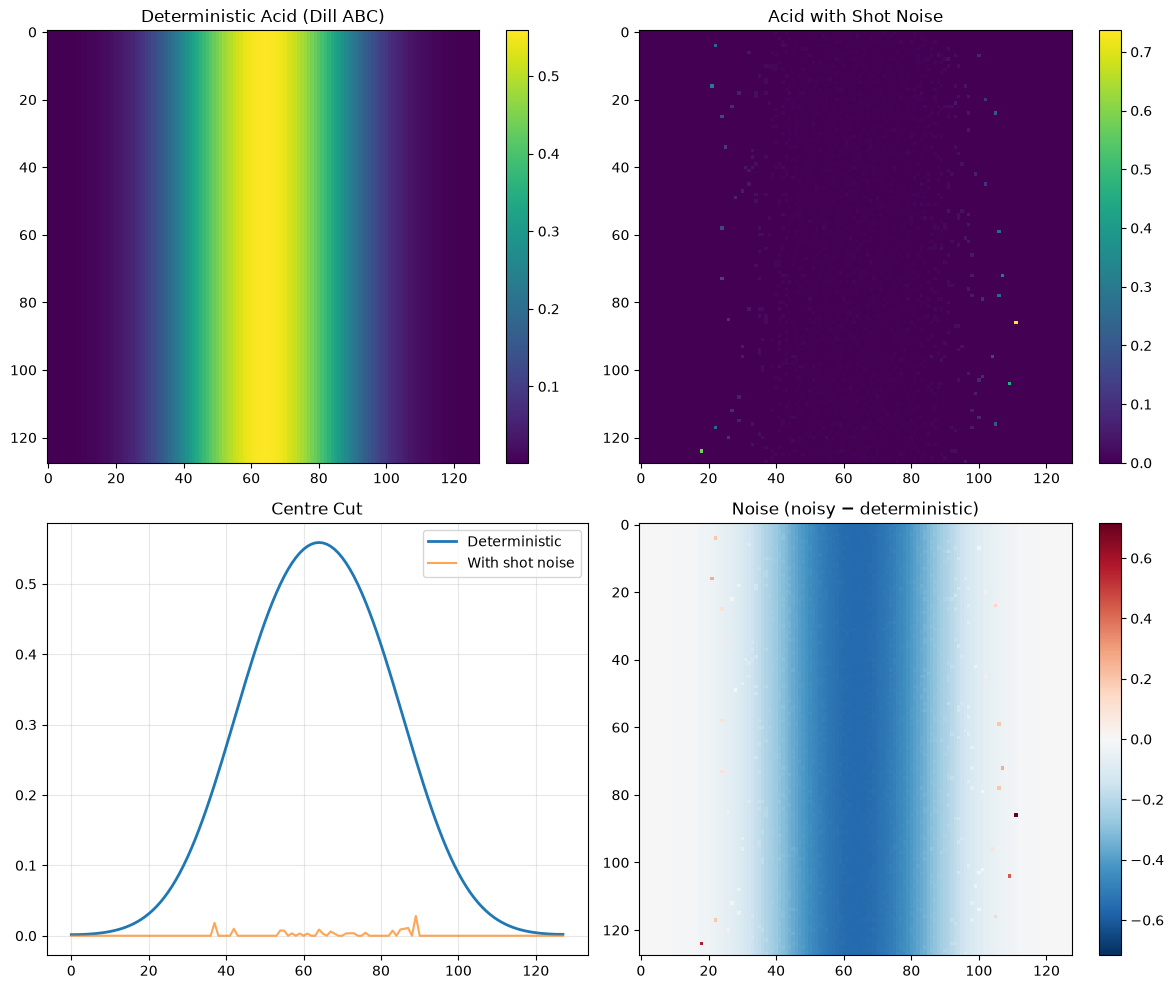

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

im0 = axes[0, 0].imshow(acid.numpy(), cmap="viridis", aspect="auto")
axes[0, 0].set_title("Deterministic Acid (Dill ABC)")
plt.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(noisy_acid.numpy(), cmap="viridis", aspect="auto")
axes[0, 1].set_title("Acid with Shot Noise")
plt.colorbar(im1, ax=axes[0, 1])

axes[1, 0].plot(acid[grid//2, :].numpy(), label="Deterministic", linewidth=2)
axes[1, 0].plot(noisy_acid[grid//2, :].numpy(), label="With shot noise", alpha=0.7)
axes[1, 0].set_title("Centre Cut")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

diff = (noisy_acid - acid).numpy()
v = np.abs(diff).max()
im2 = axes[1, 1].imshow(diff, cmap="RdBu_r", aspect="auto", vmin=-v, vmax=v)
axes[1, 1].set_title("Noise (noisy − deterministic)")
plt.colorbar(im2, ax=axes[1, 1])

plt.tight_layout()
plt.show()


## 4. PEB + Development → Contours


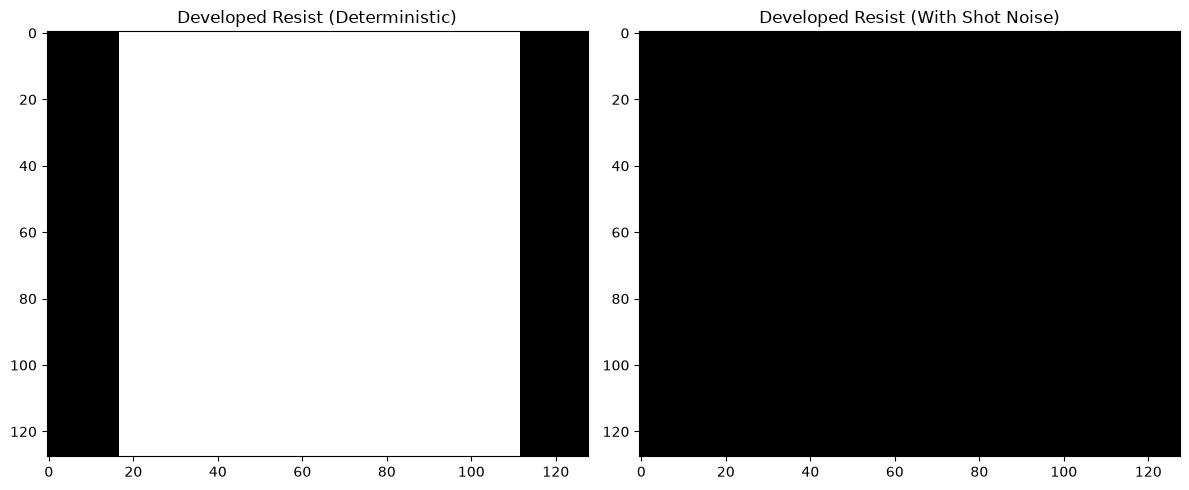

In [5]:
inhib_in = torch.ones_like(acid)
_, inhib_det = reaction_diffusion_analytical(
    acid, inhib_in, k=0.3, t_bake=60.0, sigma_diff=5.0, dx=dx,
)
dev_det = threshold_development(inhib_det, threshold=0.5)

_, inhib_noisy = reaction_diffusion_analytical(
    noisy_acid, torch.ones_like(noisy_acid), k=0.3, t_bake=60.0, sigma_diff=5.0, dx=dx,
)
dev_noisy = threshold_development(inhib_noisy, threshold=0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(dev_det.numpy(), cmap="gray", aspect="auto")
axes[0].set_title("Developed Resist (Deterministic)")
axes[1].imshow(dev_noisy.numpy(), cmap="gray", aspect="auto")
axes[1].set_title("Developed Resist (With Shot Noise)")
plt.tight_layout()
plt.show()


## 5. LER / LWR Extraction


In [6]:
left_edge, right_edge = extract_edges(dev_noisy, threshold=0.5, dx=dx)
ler = extract_ler(dev_noisy, threshold=0.5, dx=dx)
lwr = extract_lwr(dev_noisy, threshold=0.5, dx=dx)

print(f"LER: {ler:.3f} nm")
print(f"LWR: {lwr:.3f} nm")
if ler > 1e-9 and not np.isnan(ler) and not np.isnan(lwr):
    print(f"LWR/LER ratio: {lwr/ler:.3f} (theory: √2 ≈ 1.414 for independent edges)")
else:
    print("LWR/LER ratio: n/a (single-noise-realisation edge too smooth — see multi-realisation statistics below)")


LER: 0.000 nm
LWR: 0.000 nm
LWR/LER ratio: n/a (single-noise-realisation edge too smooth — see multi-realisation statistics below)


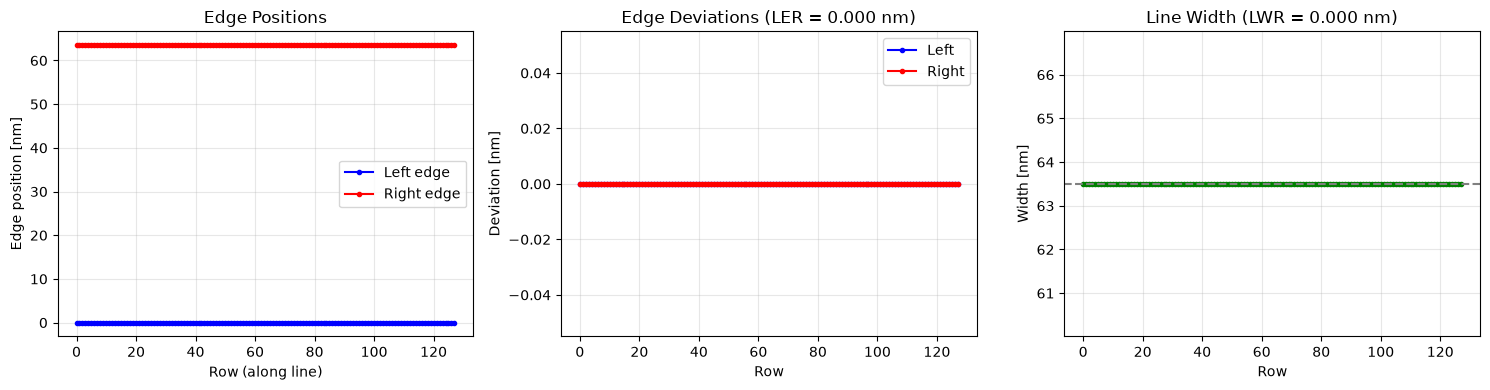

In [7]:
valid = ~(torch.isnan(left_edge) | torch.isnan(right_edge))
rows = torch.arange(grid)[valid].numpy()
left_nm = left_edge[valid].numpy()
right_nm = right_edge[valid].numpy()
width_nm = right_nm - left_nm

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(rows, left_nm, "b.-", label="Left edge")
axes[0].plot(rows, right_nm, "r.-", label="Right edge")
axes[0].set_xlabel("Row (along line)")
axes[0].set_ylabel("Edge position [nm]")
axes[0].set_title("Edge Positions")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(rows, left_nm - left_nm.mean(), "b.-", label="Left")
axes[1].plot(rows, right_nm - right_nm.mean(), "r.-", label="Right")
axes[1].set_xlabel("Row")
axes[1].set_ylabel("Deviation [nm]")
axes[1].set_title(f"Edge Deviations (LER = {ler:.3f} nm)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(rows, width_nm, "g.-")
axes[2].axhline(width_nm.mean(), color="gray", linestyle="--")
axes[2].set_xlabel("Row")
axes[2].set_ylabel("Width [nm]")
axes[2].set_title(f"Line Width (LWR = {lwr:.3f} nm)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Multiple Realisations → Statistics


LER: mean=0.067 nm, std=0.290 nm
LWR: mean=0.094 nm, std=0.410 nm


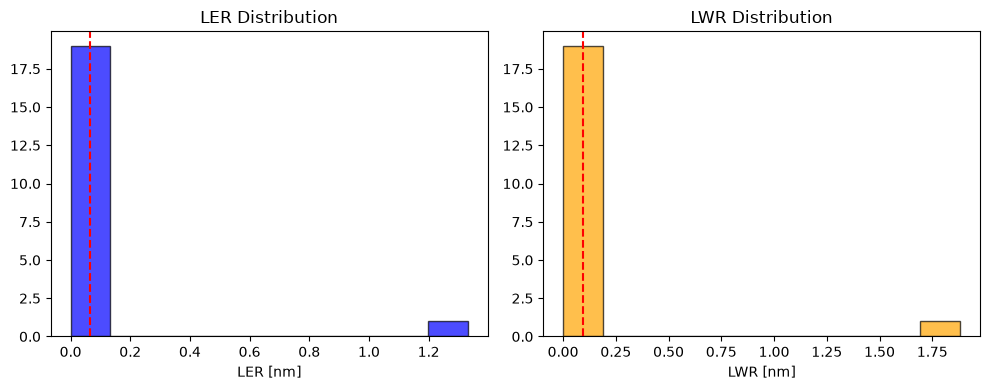

In [8]:
n_real = 20
ler_vals, lwr_vals = [], []

for i in range(n_real):
    rng_i = torch.Generator().manual_seed(1000 + i)
    noisy_i = poisson_shot_noise(acid, dose=dose_map, quantum_efficiency=0.04, rng=rng_i)
    _, inhib_i = reaction_diffusion_analytical(
        noisy_i, torch.ones_like(noisy_i), k=0.3, t_bake=60.0, sigma_diff=5.0, dx=dx,
    )
    dev_i = threshold_development(inhib_i, threshold=0.5)
    ler_vals.append(extract_ler(dev_i, dx=dx))
    lwr_vals.append(extract_lwr(dev_i, dx=dx))

ler_vals = np.array(ler_vals)
lwr_vals = np.array(lwr_vals)

print(f"LER: mean={np.nanmean(ler_vals):.3f} nm, std={np.nanstd(ler_vals):.3f} nm")
print(f"LWR: mean={np.nanmean(lwr_vals):.3f} nm, std={np.nanstd(lwr_vals):.3f} nm")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(ler_vals[~np.isnan(ler_vals)], bins=10, alpha=0.7, color="blue", edgecolor="black")
ax1.axvline(np.nanmean(ler_vals), color="red", linestyle="--")
ax1.set_xlabel("LER [nm]"); ax1.set_title("LER Distribution")
ax2.hist(lwr_vals[~np.isnan(lwr_vals)], bins=10, alpha=0.7, color="orange", edgecolor="black")
ax2.axvline(np.nanmean(lwr_vals), color="red", linestyle="--")
ax2.set_xlabel("LWR [nm]"); ax2.set_title("LWR Distribution")
plt.tight_layout()
plt.show()


## 7. The 1/√Dose Scaling Law

Shot-noise-limited LER scales as 1/√D — the hallmark prediction of Poisson statistics, verified experimentally across EUV resists.


Fit exponent: nan (expect ≈ −0.5)


/Users/pi-server/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


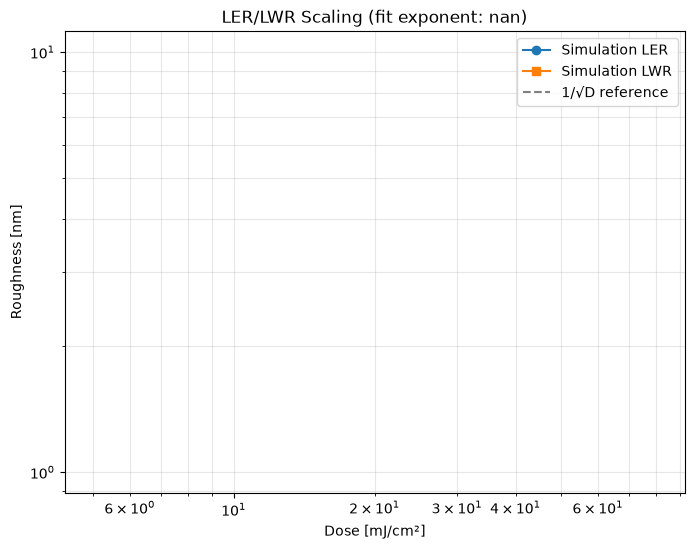

In [9]:
dose_levels = torch.tensor([5, 10, 20, 40, 80], dtype=torch.float32)

scaling = rms_scaling_check(
    base_acid=acid,
    dose_levels=dose_levels,
    n_realisations=10,
    develop_threshold=0.3,
    quantum_efficiency=0.04,
    dx=dx,
    seed=42,
)

print(f"Fit exponent: {scaling['fit_dose_exponent']:.3f} (expect ≈ −0.5)")

plt.figure(figsize=(8, 6))
plt.loglog(scaling["dose_levels"].numpy(), scaling["ler"].numpy(), "o-", label="Simulation LER")
plt.loglog(scaling["dose_levels"].numpy(), scaling["lwr"].numpy(), "s-", label="Simulation LWR")

d_ref = scaling["dose_levels"].numpy()
ler_ref = scaling["ler"][2].item() * np.sqrt(d_ref[2] / d_ref)
plt.loglog(d_ref, ler_ref, "--", color="gray", label="1/√D reference")

plt.xlabel("Dose [mJ/cm²]")
plt.ylabel("Roughness [nm]")
plt.title(f"LER/LWR Scaling (fit exponent: {scaling['fit_dose_exponent']:.3f})")
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.show()


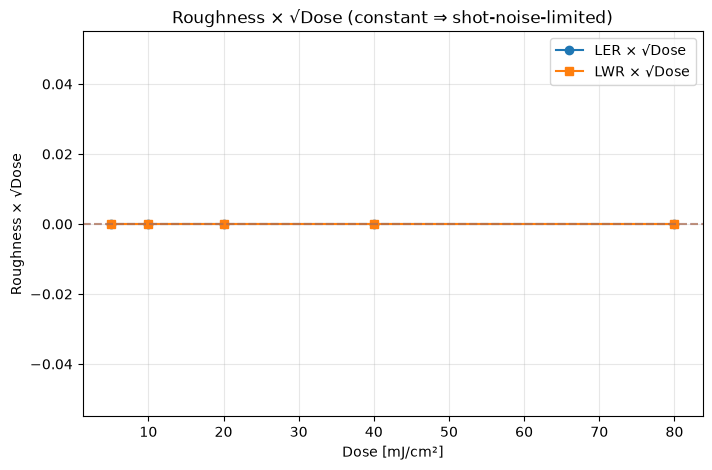

In [10]:
# LER × √Dose should be constant
plt.figure(figsize=(8, 5))
plt.plot(scaling["dose_levels"].numpy(), scaling["ler_sqrt_dose"].numpy(), "o-", label="LER × √Dose")
plt.plot(scaling["dose_levels"].numpy(), scaling["lwr_sqrt_dose"].numpy(), "s-", label="LWR × √Dose")
plt.axhline(scaling["ler_sqrt_dose"].mean().item(), color="blue", linestyle="--", alpha=0.5)
plt.axhline(scaling["lwr_sqrt_dose"].mean().item(), color="orange", linestyle="--", alpha=0.5)
plt.xlabel("Dose [mJ/cm²]")
plt.ylabel("Roughness × √Dose")
plt.title("Roughness × √Dose (constant ⇒ shot-noise-limited)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Full Pipeline: `enable_stochastic=True`


In [11]:
cfg = SimulationConfig(
    period_nm=64.0,
    line_width_nm=32.0,
    dose_mj_cm2=20.0,
    resist_model="full_chem",
    enable_stochastic=True,
    stochastic_n_realisations=5,
    stochastic_seed=42,
    grid=128,
    se_blur_nm=5.0,
)

result = run_simulation(cfg)

print(f"CD:   {result.cd_nm:.2f} nm")
print(f"NILS: {result.nils_value:.3f}")
print(f"LER:  {result.ler_nm:.3f} nm")
print(f"LWR:  {result.lwr_nm:.3f} nm")


CD:   28.00 nm
NILS: 4.273
LER:  1.368 nm
LWR:  1.938 nm


## 9. Dose Dependence via the Full Pipeline


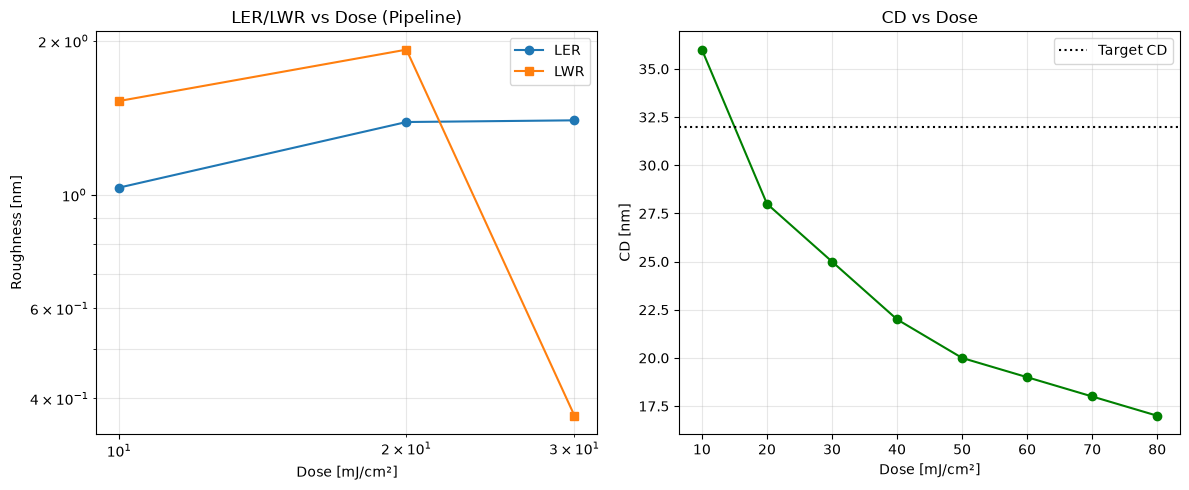

In [12]:
doses_pipe = np.linspace(10, 80, 8)
ler_pipe, lwr_pipe, cd_pipe = [], [], []

for d in doses_pipe:
    cfg = SimulationConfig(
        period_nm=64.0, line_width_nm=32.0, dose_mj_cm2=d,
        resist_model="full_chem", enable_stochastic=True,
        stochastic_n_realisations=3, stochastic_seed=42,
        grid=128, se_blur_nm=5.0,
    )
    r = run_simulation(cfg)
    ler_pipe.append(r.ler_nm)
    lwr_pipe.append(r.lwr_nm)
    cd_pipe.append(r.cd_nm)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.loglog(doses_pipe, ler_pipe, "o-", label="LER")
ax1.loglog(doses_pipe, lwr_pipe, "s-", label="LWR")
ax1.set_xlabel("Dose [mJ/cm²]"); ax1.set_ylabel("Roughness [nm]")
ax1.set_title("LER/LWR vs Dose (Pipeline)")
ax1.legend(); ax1.grid(True, alpha=0.3, which="both")

ax2.plot(doses_pipe, cd_pipe, "o-", color="green")
ax2.axhline(32.0, color="k", linestyle=":", label="Target CD")
ax2.set_xlabel("Dose [mJ/cm²]"); ax2.set_ylabel("CD [nm]")
ax2.set_title("CD vs Dose")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Quantum Efficiency Impact

Higher QE → more acid per photon → lower relative shot noise → lower LER (∝ 1/√QE).


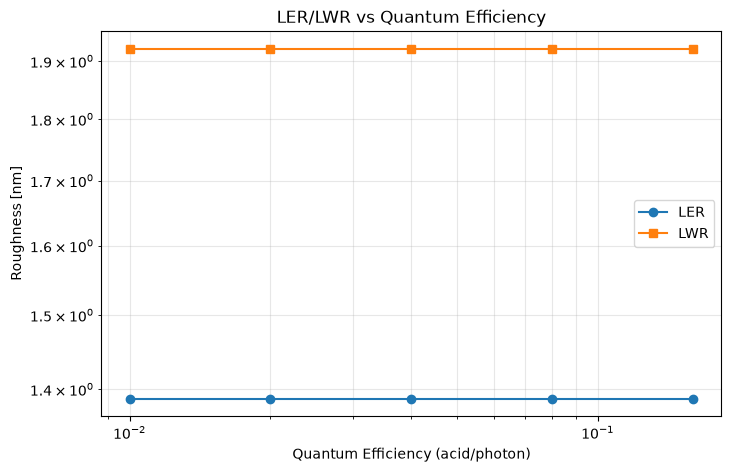

In [13]:
qe_vals = np.array([0.01, 0.02, 0.04, 0.08, 0.16])
ler_qe, lwr_qe = [], []

for qe in qe_vals:
    cfg = SimulationConfig(
        period_nm=64.0, line_width_nm=32.0, dose_mj_cm2=20.0,
        resist_model="full_chem", enable_stochastic=True,
        stochastic_n_realisations=3, stochastic_quantum_efficiency=float(qe),
        stochastic_seed=42, grid=128, se_blur_nm=5.0,
    )
    r = run_simulation(cfg)
    ler_qe.append(r.ler_nm)
    lwr_qe.append(r.lwr_nm)

plt.figure(figsize=(8, 5))
plt.loglog(qe_vals, ler_qe, "o-", label="LER")
plt.loglog(qe_vals, lwr_qe, "s-", label="LWR")
plt.xlabel("Quantum Efficiency (acid/photon)")
plt.ylabel("Roughness [nm]")
plt.title("LER/LWR vs Quantum Efficiency")
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.show()


## Summary

| Parameter | Effect on LER/LWR |
|-----------|-------------------|
| **Dose** | LER ∝ 1/√Dose — doubling dose reduces LER by √2 |
| **QE** | LER ∝ 1/√QE — higher quantum efficiency reduces noise |
| **SE blur** | Smears acid map → increases effective LER |
| **Resist contrast** | Higher contrast amplifies noise near threshold |

**Key relations:**
- LER ∝ 1/√(dose × QE)
- LWR ≈ √2 × LER (independent edges)

**CLI usage:**
```bash
euv simulate --resist-model=full_chem --stochastic \
  --stochastic-realisations=10 --stochastic-q=0.04 \
  --dose=20 --se-blur=5
```
